In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Machinery_dataset_service.csv" )

In [3]:
# Keep only rentals from 2021 onwards
df['Start of rental'] = pd.to_datetime(df['Start of rental'], errors='coerce')
df = df[df['Start of rental'].dt.year >= 2021]

# Sort by customer and rental start date
df = df.sort_values(['Customer ID', 'Start of rental'])

pair_list = []

# Loop through each customer
for customer_id, group in df.groupby('Customer ID'):
    group = group.sort_values('Start of rental')
    starts = group['Start of rental'].values
    products = group['Product Group'].values
    n = len(group)

    for i in range(n):
        window_start = starts[i]
        window_end = window_start + np.timedelta64(90, 'D')

        # Select unique products in 90-day window ahead
        mask = (starts > window_start) & (starts <= window_end)
        co_rented = set(products[mask])  # use a set to deduplicate

        for prod2 in co_rented:
            if prod2 != products[i]:
                pair = tuple(sorted([products[i], prod2]))
                pair_list.append((customer_id, pair))  # track who generated it

# Deduplicate same customer-product-pair combinations
unique_pairs = pd.DataFrame(pair_list, columns=['Customer_ID', 'Product_Pair']).drop_duplicates()

# Count frequency of each product pair
pair_counts = unique_pairs['Product_Pair'].value_counts().reset_index()
pair_counts.columns = ['Product Pair', 'Count']

# Show result
print("\nTop Unique Product Pairs Co-Rented Within 90 Days:\n")
print(pair_counts)



Top Unique Product Pairs Co-Rented Within 90 Days:

                                          Product Pair  Count
0                (Rotating Boom Lifts, Vertical Lifts)    237
1                  (Rotating Boom Lifts, Telehandlers)    199
2       (Rotating Boom Lifts, Truck Mounted Platforms)    176
3                       (Telehandlers, Vertical Lifts)    161
4            (Truck Mounted Platforms, Vertical Lifts)    139
..                                                 ...    ...
132            (Subrental Vehicles, Various Equipment)      1
133  (Electric Crane Accessory, Truck Mounted Platf...      1
134    (Rotating Boom Lifts, Truck Platform Accessory)      1
135                 (Subrental Vehicles, Truck Cranes)      1
136                     (Rent Outfitted, Rent Special)      1

[137 rows x 2 columns]


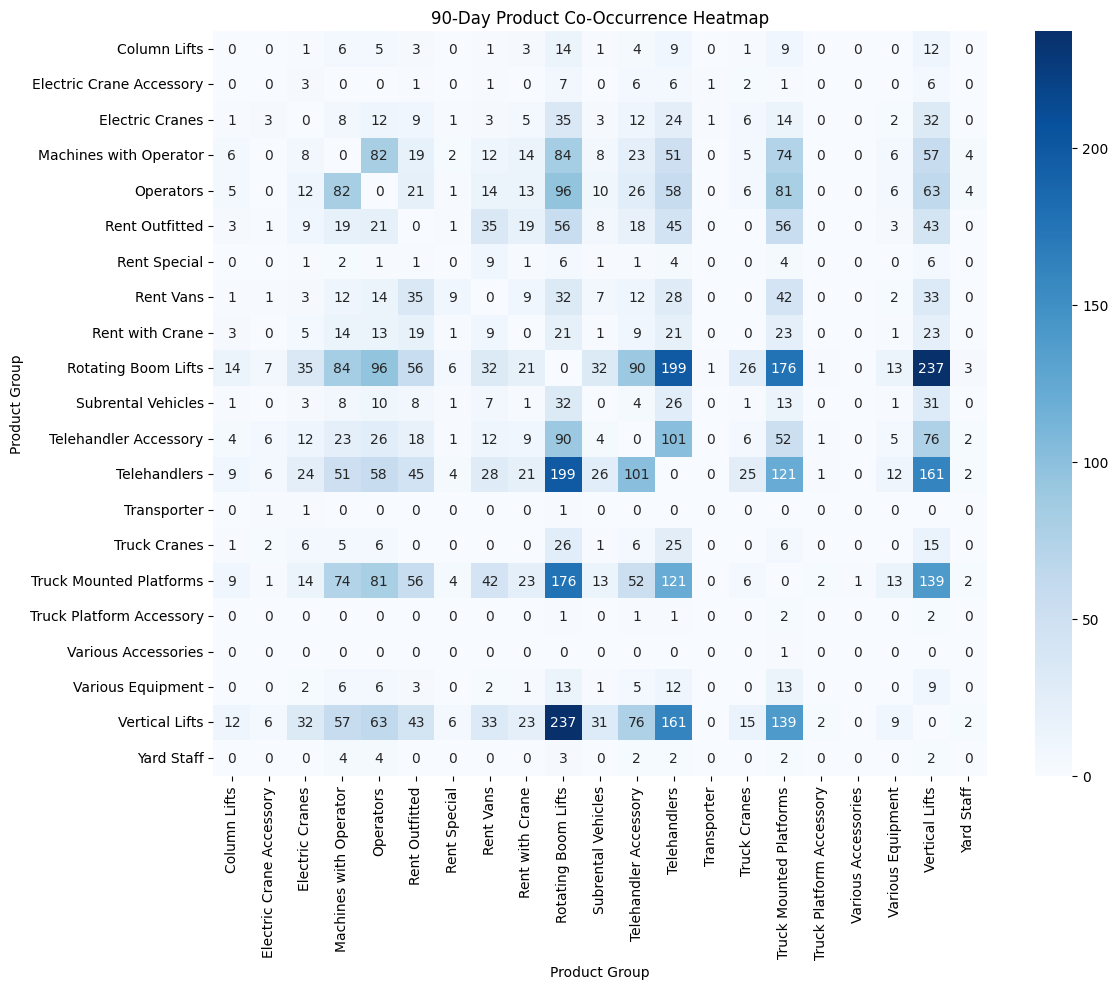

In [4]:
# Expand product pairs into rows and columns
product_set = set()
for pair in pair_counts['Product Pair']:
    product_set.update(pair)

product_list = sorted(product_set)
product_index = {p: i for i, p in enumerate(product_list)}

# Create empty co-occurrence matrix
matrix = np.zeros((len(product_list), len(product_list)), dtype=int)

# Fill matrix with counts
for (prod_a, prod_b), count in pair_counts.values:
    i, j = product_index[prod_a], product_index[prod_b]
    matrix[i, j] = count
    matrix[j, i] = count  # symmetric matrix

# Convert to DataFrame for seaborn heatmap
heatmap_df = pd.DataFrame(matrix, index=product_list, columns=product_list)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='Blues')
plt.title("90-Day Product Co-Occurrence Heatmap")
plt.xlabel("Product Group")
plt.ylabel("Product Group")
plt.tight_layout()
plt.show()

In traditional Market Basket Analysis (MBA), metrics like support, confidence, and lift are used to find product combinations that frequently occur together in customer transactions. We adapted these metrics to the B2B rental context, where products are not bought in the same basket but rented within a time window—specifically, 90 days. so in this context we define Metrics as below:  

Metric Definition:  
- Support(A):  % of customers who rented product A
- Support(A ∩ B):	% of customers who rented both A and B within a 90-day period
- Confidence(A → B);	P(B	A): Probability that a customer buys B given they bought A
- Lift(A → B): How much more likely A and B occur together than if they were independent; Strength of co-rental of A and B compared to the overall rental rate of B

In [5]:
# Filter rentals from 2021 onwards
df = df[df['Start of rental'].dt.year >= 2021]

# Sort by Customer and rental date
df = df.sort_values(['Customer ID', 'Start of rental'])

pair_list = []

# For each customer, find product pairs rented within a 90-day window
for customer_id, group in df.groupby('Customer ID'):
    group = group.sort_values('Start of rental')
    starts = group['Start of rental'].values
    products = group['Product Group'].values
    n = len(group)
    
    for i in range(n):
        window_start = starts[i]
        window_end = window_start + np.timedelta64(90, 'D')
        mask = (starts > window_start) & (starts <= window_end)
        co_rented = set(products[mask])
        
        for prod2 in co_rented:
            if prod2 != products[i]:
                pair = tuple(sorted([products[i], prod2]))
                pair_list.append((customer_id, pair))

# Step 1: Create DataFrame
pair_df = pd.DataFrame(pair_list, columns=['Customer_ID', 'Product_Pair'])
pair_df[['Product_A', 'Product_B']] = pd.DataFrame(pair_df['Product_Pair'].tolist(), index=pair_df.index)

# Step 2: Support for single products
all_rentals = pd.concat([
    pair_df[['Customer_ID', 'Product_A']].rename(columns={'Product_A': 'Product'}),
    pair_df[['Customer_ID', 'Product_B']].rename(columns={'Product_B': 'Product'})
])
support_single = all_rentals.drop_duplicates().groupby('Product')['Customer_ID'].nunique()
total_customers = all_rentals['Customer_ID'].nunique()
support_single = support_single / total_customers

# Step 3: Support for product pairs
support_pair = pair_df.drop_duplicates(subset=['Customer_ID', 'Product_Pair']) \
                      .groupby('Product_Pair')['Customer_ID'].nunique()
support_pair = support_pair / total_customers

# Step 4: Compute Confidence and Lift
results = []

for (prod_a, prod_b), supp_ab in support_pair.items():
    supp_a = support_single.get(prod_a, 0)
    supp_b = support_single.get(prod_b, 0)
    
    if supp_a > 0 and supp_b > 0:
        conf_ab = supp_ab / supp_a
        conf_ba = supp_ab / supp_b
        lift_ab = conf_ab / supp_b
        lift_ba = conf_ba / supp_a

        results.append({
            'Product A': prod_a,
            'Product B': prod_b,
            'Support A': round(supp_a, 4),
            'Support B': round(supp_b, 4),
            'Support (A ∩ B)': round(supp_ab, 4),
            'Confidence (A → B)': round(conf_ab, 4),
            'Confidence (B → A)': round(conf_ba, 4),
            'Lift (A → B)': round(lift_ab, 4),
            'Lift (B → A)': round(lift_ba, 4)
        })

# Step 5: Output DataFrame
mba_df = pd.DataFrame(results).sort_values(by='Lift (A → B)', ascending=False)

# Save or inspect
mba_df.to_csv("mba_rules_90day.csv", index=False)
mba_df.head(10)

,Product A,Product B,Support A,Support B,Support (A ∩ B),Confidence (A → B),Confidence (B → A),Lift (A → B),Lift (B → A)
19,Electric Crane Accessory,Transporter,0.0208,0.0017,0.0017,0.0833,1.0000,48.0833,48.0833
33,Electric Cranes,Transporter,0.0763,0.0017,0.0017,0.0227,1.0000,13.1136,13.1136
75,Rent Special,Rent Vans,0.0225,0.1386,0.0156,0.6923,0.1125,4.9933,4.9933
13,Electric Crane Accessory,Electric Cranes,0.0208,0.0763,0.0052,0.2500,0.0682,3.2784,3.2784
51,Machines with Operator,Yard Staff,0.2565,0.0087,0.0069,0.0270,0.8000,3.1189,3.1189
64,Operators,Yard Staff,0.2946,0.0087,0.0069,0.0235,0.8000,2.7153,2.7153
20,Electric Crane Accessory,Truck Cranes,0.0208,0.0624,0.0035,0.1667,0.0556,2.6713,2.6713
5,Column Lifts,Rent with Crane,0.0312,0.0711,0.0052,0.1667,0.0732,2.3455,2.3455
67,Rent Outfitted,Rent with Crane,0.1993,0.0711,0.0329,0.1652,0.4634,2.3251,2.3251
66,Rent Outfitted,Rent Vans,0.1993,0.1386,0.0607,0.3043,0.4375,2.1951,2.1951


THRESHHOLD DEFINITION

To identify meaningful product pairs for cross-selling, we evaluated the generated association rules based on three key metrics:

Metric	Definition	Recommended Threshold:  
- Support (A ∩ B)	> 0.005 (0.5%)
- Confidence (A → B) > 0.3
- Lift (A → B)-How much more likely B is to be bought with A compared to random chance	> 2.0

Only rules that meet all these thresholds are considered strong and actionable for cross-sell strategies.

RESULT:  
considering the Threshhold, We accepted these tules as effective and useful for cross-selling:
- (A): Telehandler Accessory, (B): Various Equipment; Confidence (A→B):	0.333, Lift (A→B): 7.88	Very strong lift and solid confidence — ideal pair
- (A): Rent Special, (B): Rent Vans;	Confidence (A→B): 0.692, Lift (A→B): 4.77	High conversion likelihood — bundle candidate
- (A): Telehandler Accessory, (B): Truck Mounted Platforms; Confidence (A→B): 1.000, Lift (A→B):1.90	Perfect confidence but marginal lift — context-specific

These three product combinations show strong cross-sell potential. Especially the first two pairs can be leveraged in marketing campaigns or rental bundle designs.

Product Sequence Analysis

In [6]:
# Step 1: Sort rentals by customer and rental date
df = df.sort_values(by=['Customer ID', 'Start of rental'])

# Step 2: Create ordered product sequence for each customer
sequence_df = df.groupby('Customer ID')['Product Group'].apply(list).reset_index()
sequence_df.columns = ['Customer ID', 'Rental Sequence']

# show product sequences for the first few customers
print(sequence_df.head(10))

  Customer ID                                    Rental Sequence
0      cust01                                   [Rent Outfitted]
1      cust02  [Subrental Vehicles, Subrental Vehicles, Subre...
2      cust03  [Rent Vans, Rent Vans, Rent Vans, Rent Vans, R...
3      cust04                              [Rotating Boom Lifts]
4      cust05  [Rotating Boom Lifts, Rotating Boom Lifts, Rot...
5      cust06  [Truck Mounted Platforms, Truck Mounted Platfo...
6      cust07  [Rent Vans, Rent Vans, Rent Special, Rent Vans...
7      cust09  [Rent Outfitted, Telehandlers, Rotating Boom L...
8      cust10  [Rent Vans, Rent Vans, Rent Vans, Rent Vans, R...
9     cust100  [Truck Mounted Platforms, Truck Mounted Platfo...


In [7]:
from collections import Counter
from itertools import tee, islice

# Define a function to extract consecutive product transitions (e.g., A → B → C → D → ...)
def extract_transitions(product_sequence):
    # Creates pairs (A→B, B→C, ...) from a list
    a, b = tee(product_sequence)
    next(b, None)
    return list(zip(a, b))

# Apply transition extraction across all customer sequences
all_transitions = []

for seq in sequence_df['Rental Sequence']:
    all_transitions.extend(extract_transitions(seq))

# Count frequency of each unique transition
transition_counts = Counter(all_transitions)
transition_df = pd.DataFrame(transition_counts.items(), columns=['Transition', 'Count'])
transition_df[['From Product', 'To Product']] = pd.DataFrame(transition_df['Transition'].tolist(), index=transition_df.index)
transition_df = transition_df[['From Product', 'To Product', 'Count']].sort_values(by='Count', ascending=False)

# Save or inspect the transition DataFrame
print(transition_df.head(10))


               From Product               To Product  Count
14      Rotating Boom Lifts      Rotating Boom Lifts   6807
10           Vertical Lifts           Vertical Lifts   5439
32             Telehandlers             Telehandlers   3209
61    Telehandler Accessory    Telehandler Accessory   3121
12  Truck Mounted Platforms  Truck Mounted Platforms   2716
40   Machines with Operator                Operators   1578
52             Column Lifts             Column Lifts   1181
89                Operators   Machines with Operator   1050
17      Rotating Boom Lifts           Vertical Lifts    886
18           Vertical Lifts      Rotating Boom Lifts    873


In [8]:
# Calculate total transitions from each product to compute confidence
from_totals = transition_df.groupby('From Product')['Count'].sum().to_dict()

# Add confidence = count(A→B) / total transitions from A
transition_df['Confidence (A → B)'] = transition_df.apply(
    lambda row: round(row['Count'] / from_totals.get(row['From Product'], 1), 4), axis=1
)
# Save or inspect the transition DataFrame with confidence
transition_df = transition_df.sort_values(by='Confidence (A → B)', ascending=False)
print(transition_df.head(10))

# Filter transitions with confidence greater than 0.7
high_confidence_df = transition_df[transition_df['Confidence (A → B)'] > 0.7].reset_index(drop=True)
high_confidence_df.head(10)


                 From Product                To Product  Count  \
197       Various Accessories   Truck Mounted Platforms      1   
164               Transporter               Transporter      1   
52               Column Lifts              Column Lifts   1181   
145  Electric Crane Accessory  Electric Crane Accessory    102   
61      Telehandler Accessory     Telehandler Accessory   3121   
40     Machines with Operator                 Operators   1578   
13                  Rent Vans                 Rent Vans    738   
0          Subrental Vehicles        Subrental Vehicles    257   
20             Rent Outfitted            Rent Outfitted    791   
14        Rotating Boom Lifts       Rotating Boom Lifts   6807   

     Confidence (A → B)  
197              1.0000  
164              1.0000  
52               0.9307  
145              0.8793  
61               0.8367  
40               0.7906  
13               0.7768  
0                0.7199  
20               0.7158  
14           

,From Product,To Product,Count,Confidence (A → B)
0,Various Accessories,Truck Mounted Platforms,1,1.0000
1,Transporter,Transporter,1,1.0000
2,Column Lifts,Column Lifts,1181,0.9307
3,Electric Crane Accessory,Electric Crane Accessory,102,0.8793
4,Telehandler Accessory,Telehandler Accessory,3121,0.8367
5,Machines with Operator,Operators,1578,0.7906
6,Rent Vans,Rent Vans,738,0.7768
7,Subrental Vehicles,Subrental Vehicles,257,0.7199
8,Rent Outfitted,Rent Outfitted,791,0.7158
9,Rotating Boom Lifts,Rotating Boom Lifts,6807,0.7143
